In [1]:
import pandas as pd

In [2]:
df  = pd.read_csv('/Users/drazenzack/Desktop/LLM_model/Model_Results/test_results.csv')

In [3]:
new_model = df.sort_values(by=['similarity_score'], ascending=False)

In [4]:
df2  = pd.read_csv('/Users/drazenzack/Desktop/LLM_model/Model_Results/test_results_rag.csv')
rag_model = df2.sort_values(by=['similarity_score'], ascending=False)

In [5]:
# 2 * (number of matching characters)/ (total characters in both strings)
print('Base Model Similarity:', rag_model['similarity_score'].mean())

Base Model Similarity: 0.7718666666666667


In [6]:
# 2 * (number of matching characters)/ (total characters in both strings)
print('New Model Similarity:', new_model['similarity_score'].mean())

New Model Similarity: 0.7424666666666667


In [16]:
new_model.sort_values('similarity_score')

,test_case_id,instruction,expected_output,generated_output,similarity_score,is_correct,method_correct,error
96,97,Return top 184.0 rows by day_ahead.,"df.nlargest(189.0, 'pred')",df.loc[df['day_ahead'].isin(df['day_ahead'].va...,0.20,False,False,NaN
83,84,Return bottom 23.0 rows by pred.,"df.nsmallest(153.0, 'day_ahead')","df.iloc[-23:, :]",0.29,False,False,NaN
44,45,Return top 197.0 rows by pred.,"df.nlargest(45.0, 'power_OBS')",df.head(197),0.29,False,False,NaN
65,66,Return top 116.0 rows by day_ahead.,"df.nlargest(127.0, 'pred')",df.loc[df['day_ahead'].argsort()[-116:]],0.33,False,False,NaN
107,108,Return top 84.0 rows by day_ahead.,"df.nlargest(52.0, 'pred')",df.loc[df['day_ahead'].argsort()[-84:]],0.34,False,False,NaN
...,...,...,...,...,...,...,...,...
136,137,Filter rows where gain is negative.,df[df['gain'] < 0],df[df['gain'] < 0],1.00,True,True,NaN
7,8,Filter rows where gain is negative.,df[df['gain'] < 0],df[df['gain'] < 0],1.00,True,True,NaN
4,5,Count unique values of day_ahead.,df['day_ahead'].nunique(),df['day_ahead'].nunique(),1.00,True,True,NaN
95,96,Filter rows where gain is negative.,df[df['gain'] < 0],df[df['gain'] < 0],1.00,True,True,NaN


In [8]:
rag_model.sort_values('similarity_score')

,test_case_id,instruction,expected_output,generated_output,similarity_score,is_correct,method_correct,error
12,13,Return top 138.0 rows by day_ahead.,"df.nlargest(64.0, 'day_ahead')",df.loc[:137],0.19,False,False,NaN
63,64,Return bottom 127.0 rows by pred.,"df.nsmallest(16.0, 'day_ahead')",df[df['pred'] <= 127.0],0.22,False,False,NaN
81,82,Return bottom 63.0 rows by power_OBS.,"df.nsmallest(140.0, 'power_OBS')",df.iloc[:63],0.23,False,False,NaN
83,84,Return bottom 23.0 rows by pred.,"df.nsmallest(153.0, 'day_ahead')",df.iloc[:23],0.23,False,False,NaN
41,42,Return bottom 79.0 rows by pred.,"df.nsmallest(70.0, 'power_OBS')",df[df['pred'] <= 79.0].head(79),0.23,False,False,NaN
...,...,...,...,...,...,...,...,...
148,149,Compute the sum of day_ahead grouped by models.,df.groupby('models')['day_ahead'].sum(),df.groupby('models')['day_ahead'].sum(),1.00,True,True,NaN
126,127,Filter rows where gain is negative.,df[df['gain'] < 0],df[df['gain'] < 0],1.00,True,True,NaN
91,92,Compute the min of power_OBS grouped by LZ.,df.groupby('LZ')['power_OBS'].min(),df.groupby('LZ')['power_OBS'].min(),1.00,True,True,NaN
127,128,Filter rows where gain is negative.,df[df['gain'] < 0],df[df['gain'] < 0],1.00,True,True,NaN


In [9]:
num = 13

In [10]:
print(new_model[new_model['test_case_id'] == num]['instruction'].values[0])
print('------------------')
print(new_model[new_model['test_case_id'] == num]['expected_output'].values[0])
print('-----')
print(new_model[new_model['test_case_id'] == num]['generated_output'].values[0])

Return top 138.0 rows by day_ahead.
------------------
df.nlargest(64.0, 'day_ahead')
-----
df.loc[df['day_ahead'].argsort()[-138:]]


In [11]:
print(rag_model[rag_model['test_case_id'] == num]['instruction'].values[0])
print('------------------')
print(rag_model[rag_model['test_case_id'] == num]['expected_output'].values[0])
print('-----')
print(rag_model[rag_model['test_case_id'] == num]['generated_output'].values[0])

Return top 138.0 rows by day_ahead.
------------------
df.nlargest(64.0, 'day_ahead')
-----
df.loc[:137]


In [14]:
print('New Model:', new_model["is_correct"].mean().round(4))
print('Rag Model:', rag_model["is_correct"].mean().round(4))

New Model: 0.2
Rag Model: 0.3


In [15]:
print('New Model:', new_model["method_correct"].mean().round(4))
print('Rag Model:', rag_model["method_correct"].mean().round(4))

New Model: 0.62
Rag Model: 0.7533


In [17]:
print('New Model:', new_model.loc[~new_model["is_correct"], "similarity_score"].mean())
print('Rag Model:', rag_model.loc[~rag_model["is_correct"], "similarity_score"].mean())

New Model: 0.6843333333333332
Rag Model: 0.6877142857142856


In [19]:
print('New Model:', new_model.loc[~new_model["method_correct"], "similarity_score"].mean())
print('Rag Model:', rag_model.loc[~rag_model["method_correct"], "similarity_score"].mean())

New Model: 0.5733333333333334
Rag Model: 0.4897297297297298


In [20]:
near_miss_rate = (
    (new_model["similarity_score"] >= 0.8) &
    (new_model["similarity_score"] < .89)
).mean()

near_miss_rate

np.float64(0.14666666666666667)

In [21]:
near_miss_rate = (
    (rag_model["similarity_score"] >= 0.8) &
    (rag_model["similarity_score"] < .89)
).mean()

near_miss_rate

np.float64(0.15333333333333332)

In [22]:
print('New Model:', (new_model["similarity_score"] < 0.7).mean())
print('Rag Model:', (rag_model["similarity_score"] < 0.7).mean())

New Model: 0.37333333333333335
Rag Model: 0.24


In [23]:
new_model.assign(
    task_type=df["instruction"].str.split().str[0]
).groupby("task_type").agg(
    accuracy=("is_correct", "mean"),
    avg_similarity=("similarity_score", "mean"),
    count=("test_case_id", "count")
).sort_values("accuracy")

,accuracy,avg_similarity,count
task_type,,,
Extract,0.000000,0.810000,2
Get,0.000000,0.730000,11
Return,0.000000,0.434286,14
Compute,0.125000,0.743958,48
Sort,0.200000,0.762000,5
Filter,0.327869,0.798852,61
Count,0.333333,0.821111,9


In [24]:
rag_model.assign(
    task_type=df["instruction"].str.split().str[0]
).groupby("task_type").agg(
    accuracy=("is_correct", "mean"),
    avg_similarity=("similarity_score", "mean"),
    count=("test_case_id", "count")
).sort_values("accuracy")

,accuracy,avg_similarity,count
task_type,,,
Count,0.000000,0.655556,9
Extract,0.000000,0.390000,2
Return,0.000000,0.280714,14
Get,0.090909,0.776364,11
Sort,0.200000,0.808000,5
Compute,0.270833,0.857500,48
Filter,0.491803,0.843115,61


In [25]:
final_score = (
    0.3 * new_model["is_correct"].mean() +
    0.4 * new_model["method_correct"].mean() +
    0.3 * new_model["similarity_score"].mean()
)

final_score

np.float64(0.53074)

In [26]:
final_score = (
    0.3 * rag_model["is_correct"].mean() +
    0.4 * rag_model["method_correct"].mean() +
    0.3 * rag_model["similarity_score"].mean()
)

final_score

np.float64(0.6228933333333333)

In [27]:
cols = ["test_case_id", "is_correct", "similarity_score", "method_correct"]

new2 = new_model[cols].sort_values("test_case_id").reset_index(drop=True)
base2 = rag_model[cols].sort_values("test_case_id").reset_index(drop=True)

assert (new2["test_case_id"] == base2["test_case_id"]).all()

In [28]:
# from scipy.stats import ttest_rel

# t_stat, p_value = ttest_rel(
#     new2["similarity_score"],
#     base2["similarity_score"]
# )

# t_stat, p_value

In [29]:

# import numpy as np
# diff = new2["similarity_score"] - base2["similarity_score"]

# boot_means = []
# rng = np.random.default_rng(42)

# for _ in range(10000):
#     sample = rng.choice(diff, size=len(diff), replace=True)
#     boot_means.append(sample.mean())

# ci_low, ci_high = np.percentile(boot_means, [2.5, 97.5])
# mean_diff = diff.mean()

# mean_diff, ci_low, ci_high

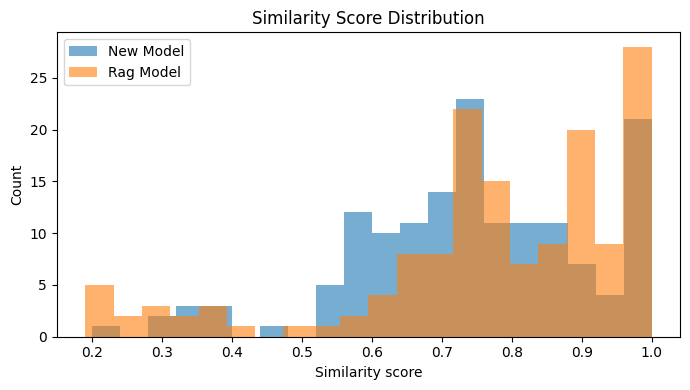

In [30]:
import matplotlib.pyplot as plt

plt.figure(figsize=(7,4))
plt.hist(new2["similarity_score"], bins=20, alpha=0.6, label="New Model")
plt.hist(base2["similarity_score"], bins=20, alpha=0.6, label="Rag Model")
plt.xlabel("Similarity score")
plt.ylabel("Count")
plt.legend()
plt.title("Similarity Score Distribution")
plt.tight_layout()
plt.show()

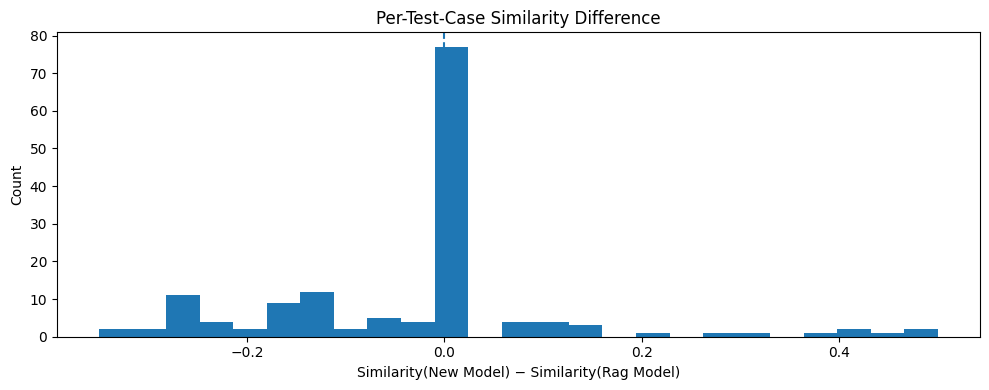

In [31]:
diff = new2["similarity_score"] - base2["similarity_score"]

plt.figure(figsize=(10,4))
plt.hist(diff, bins=25)
plt.axvline(0, linestyle="--")
plt.xlabel("Similarity(New Model) − Similarity(Rag Model)")
plt.ylabel("Count")
plt.title("Per-Test-Case Similarity Difference")
plt.tight_layout()
plt.show()

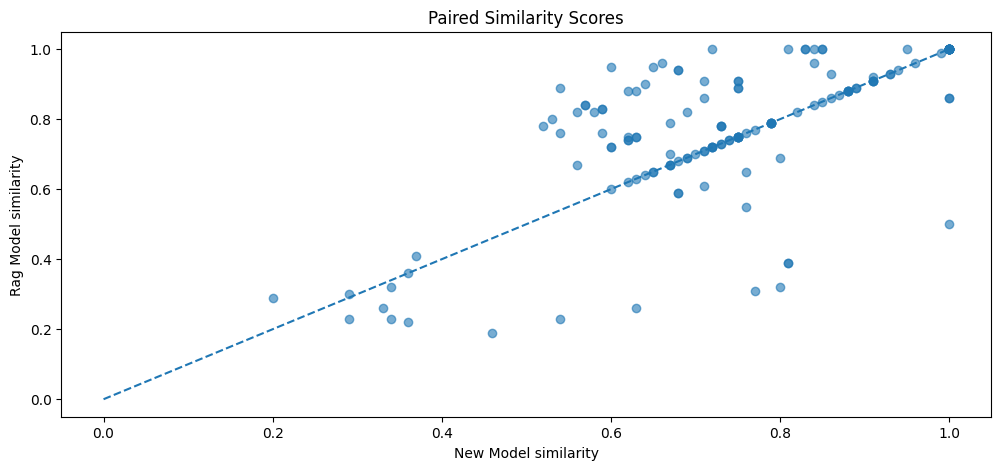

In [32]:
plt.figure(figsize=(12,5))
plt.scatter(
    x= new2["similarity_score"],
    y= base2["similarity_score"],
    alpha=0.6,
)
plt.plot([0,1], [0,1], linestyle="--")
plt.xlabel("New Model similarity")
plt.ylabel("Rag Model similarity")
plt.title("Paired Similarity Scores")
# plt.tight_layout()
plt.show()

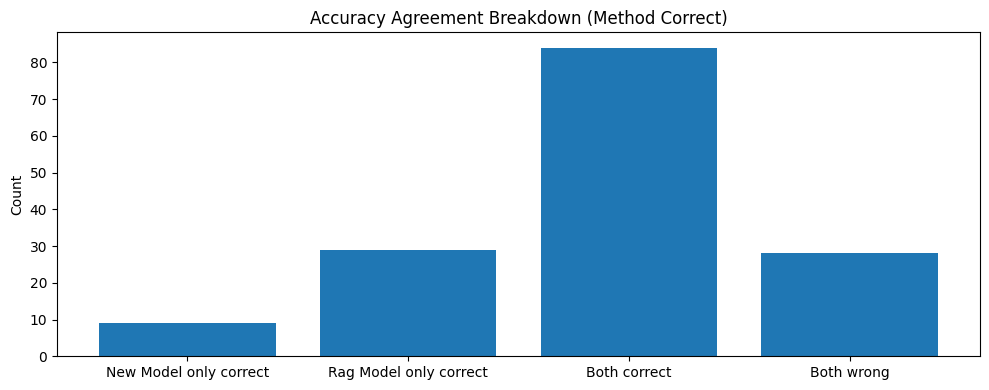

In [33]:
a_only = ((new2.method_correct) & (~base2.method_correct)).sum()
b_only = ((~new2.method_correct) & (base2.method_correct)).sum()
both = ((new2.method_correct) & (base2.method_correct)).sum()
neither = ((~new2.method_correct) & (~base2.method_correct)).sum()

plt.figure(figsize=(10,4))
plt.bar(
    ["New Model only correct", "Rag Model only correct", "Both correct", "Both wrong"],
    [a_only, b_only, both, neither]
)
plt.ylabel("Count")
plt.title("Accuracy Agreement Breakdown (Method Correct)")
plt.tight_layout()
plt.show()

/var/folders/tt/5g7kjc2j66b3f51x1pj2tcqh0000gn/T/ipykernel_52572/3988834128.py:5: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot([err_new, err_base], labels=["New Model", "Rag Model"])


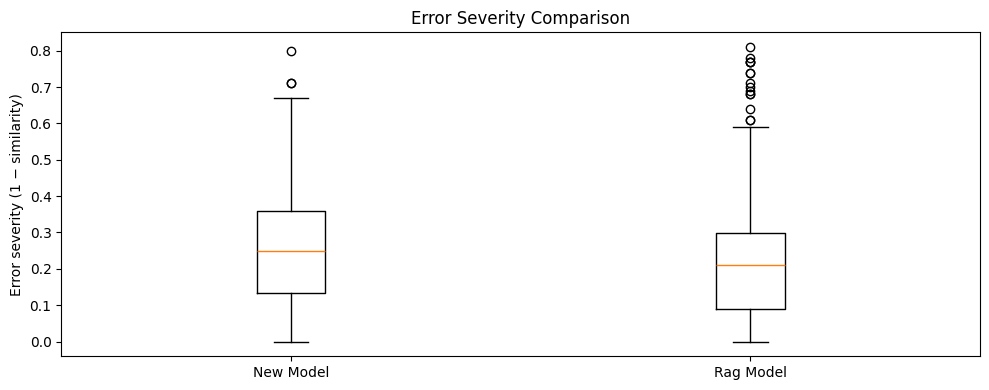

In [34]:
err_new = 1 - new2["similarity_score"]
err_base = 1 - base2["similarity_score"]

plt.figure(figsize=(10,4))
plt.boxplot([err_new, err_base], labels=["New Model", "Rag Model"])
plt.ylabel("Error severity (1 − similarity)")
plt.title("Error Severity Comparison")
plt.tight_layout()
plt.show()

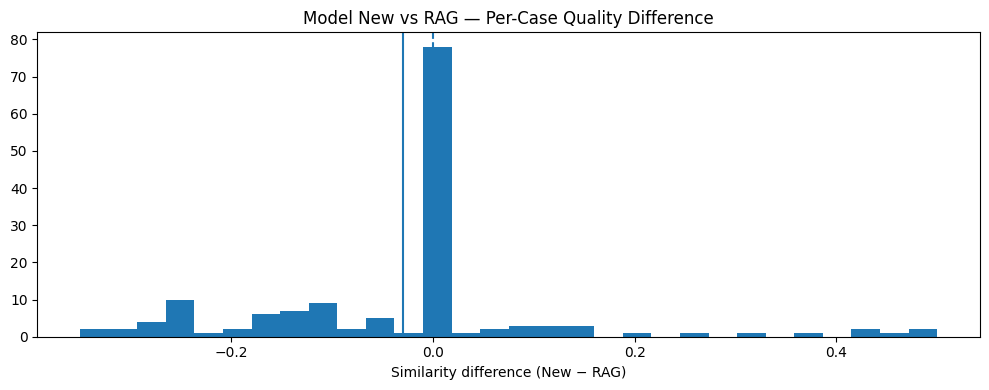

In [36]:
plt.figure(figsize=(10,4))
plt.hist(diff, bins=30)
plt.axvline(0, linestyle="--")
plt.axvline(diff.mean())
plt.title("Model New vs RAG — Per-Case Quality Difference")
plt.xlabel("Similarity difference (New − RAG)")
plt.tight_layout()
plt.show()

In [37]:
new_model["task_type"] = (
    new_model["instruction"]
    .str.lower()
    .str.extract(r'^(sort|compute|filter|extract|group)')
    .fillna("other")
)

rag_model["task_type"] = (
    rag_model["instruction"]
    .str.lower()
    .str.extract(r'^(sort|compute|filter|extract|group)')
    .fillna("other")
)

In [38]:
task_stats_new = (
    new_model.groupby("task_type")
      .agg(
          accuracy=("is_correct", "mean"),
          avg_similarity=("similarity_score", "mean"),
          error_rate=("is_correct", lambda x: 1 - x.mean()),
          avg_error_severity=("similarity_score", lambda x: (1 - x).mean()),
          count=("test_case_id", "count")
      )
      .sort_values("accuracy")
)

task_stats_new

,accuracy,avg_similarity,error_rate,avg_error_severity,count
task_type,,,,,
extract,0.000000,0.810000,1.000000,0.190000,2
other,0.088235,0.632353,0.911765,0.367647,34
compute,0.125000,0.743958,0.875000,0.256042,48
sort,0.200000,0.762000,0.800000,0.238000,5
filter,0.327869,0.798852,0.672131,0.201148,61


In [39]:
task_stats_base = (
rag_model.groupby("task_type")
      .agg(
          accuracy=("is_correct", "mean"),
          avg_similarity=("similarity_score", "mean"),
          error_rate=("is_correct", lambda x: 1 - x.mean()),
          avg_error_severity=("similarity_score", lambda x: (1 - x).mean()),
          count=("test_case_id", "count")
      )
      .sort_values("accuracy")
)

task_stats_base

,accuracy,avg_similarity,error_rate,avg_error_severity,count
task_type,,,,,
extract,0.000000,0.390000,1.000000,0.610000,2
other,0.029412,0.540294,0.970588,0.459706,34
sort,0.200000,0.808000,0.800000,0.192000,5
compute,0.270833,0.857500,0.729167,0.142500,48
filter,0.491803,0.843115,0.508197,0.156885,61


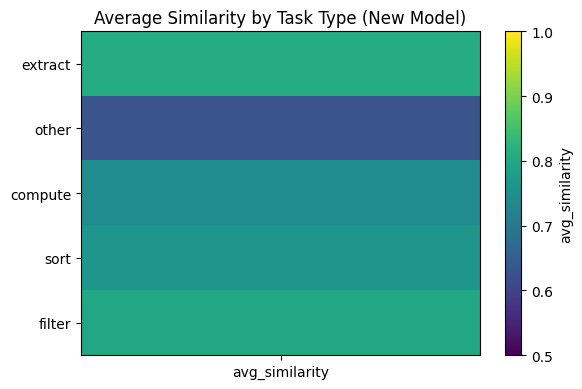

In [40]:
plt.figure(figsize=(6,4))
plt.imshow(
    task_stats_new[["avg_similarity"]].values,
    aspect="auto",
    vmin=0.5,
    vmax=1.0
)
plt.xticks([0], ["avg_similarity"])
plt.yticks(range(len(task_stats_new)), task_stats_new.index)
plt.colorbar(label="avg_similarity")
plt.title("Average Similarity by Task Type (New Model)")
plt.tight_layout()
plt.show()

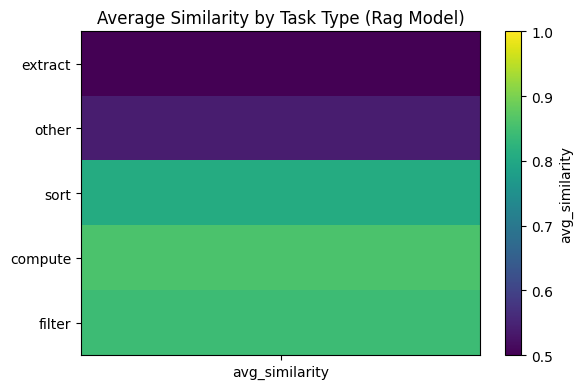

In [41]:
plt.figure(figsize=(6,4))
plt.imshow(
    task_stats_base[["avg_similarity"]].values,
    aspect="auto",
    vmin=0.5,
    vmax=1.0
)
plt.xticks([0], ["avg_similarity"])
plt.yticks(range(len(task_stats_base)), task_stats_base.index)
plt.colorbar(label="avg_similarity")
plt.title("Average Similarity by Task Type (Rag Model)")
plt.tight_layout()
plt.show()

/var/folders/tt/5g7kjc2j66b3f51x1pj2tcqh0000gn/T/ipykernel_52572/295813842.py:8: FutureWarning: The default value of observed=False is deprecated and will change to observed=True in a future version of pandas. Specify observed=False to silence this warning and retain the current behavior
  new_model.pivot_table(


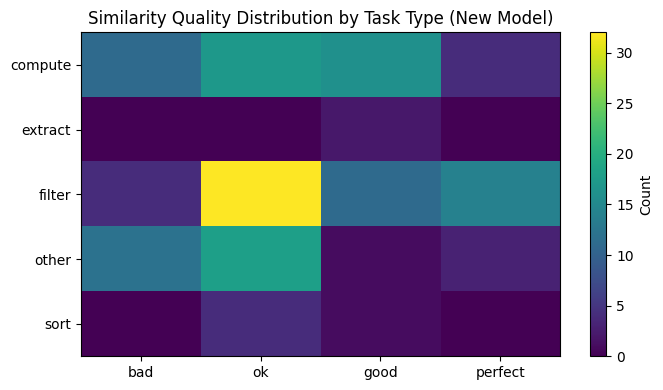

In [42]:
new_model["sim_bin"] = pd.cut(
    new_model["similarity_score"],
    bins=[0, 0.6, 0.8, 0.95, 1.0],
    labels=["bad", "ok", "good", "perfect"]
)

pivot = (
    new_model.pivot_table(
        index="task_type",
        columns="sim_bin",
        values="test_case_id",
        aggfunc="count",
        fill_value=0
    )
)

plt.figure(figsize=(7,4))
plt.imshow(pivot.values, aspect="auto")
plt.xticks(range(len(pivot.columns)), pivot.columns)
plt.yticks(range(len(pivot.index)), pivot.index)
plt.colorbar(label="Count")
plt.title("Similarity Quality Distribution by Task Type (New Model)")
plt.tight_layout()
plt.show()

/var/folders/tt/5g7kjc2j66b3f51x1pj2tcqh0000gn/T/ipykernel_52572/2442032237.py:8: FutureWarning: The default value of observed=False is deprecated and will change to observed=True in a future version of pandas. Specify observed=False to silence this warning and retain the current behavior
  rag_model.pivot_table(


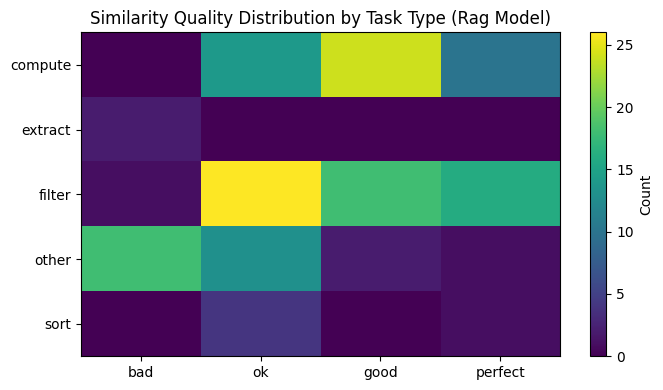

In [44]:
rag_model["sim_bin"] = pd.cut(
    rag_model["similarity_score"],
    bins=[0, 0.6, 0.8, 0.95, 1.0],
    labels=["bad", "ok", "good", "perfect"]
)

pivot = (
    rag_model.pivot_table(
        index="task_type",
        columns="sim_bin",
        values="test_case_id",
        aggfunc="count",
        fill_value=0
    )
)

plt.figure(figsize=(7,4))
plt.imshow(pivot.values, aspect="auto")
plt.xticks(range(len(pivot.columns)), pivot.columns)
plt.yticks(range(len(pivot.index)), pivot.index)
plt.colorbar(label="Count")
plt.title("Similarity Quality Distribution by Task Type (Rag Model)")
plt.tight_layout()
plt.show()

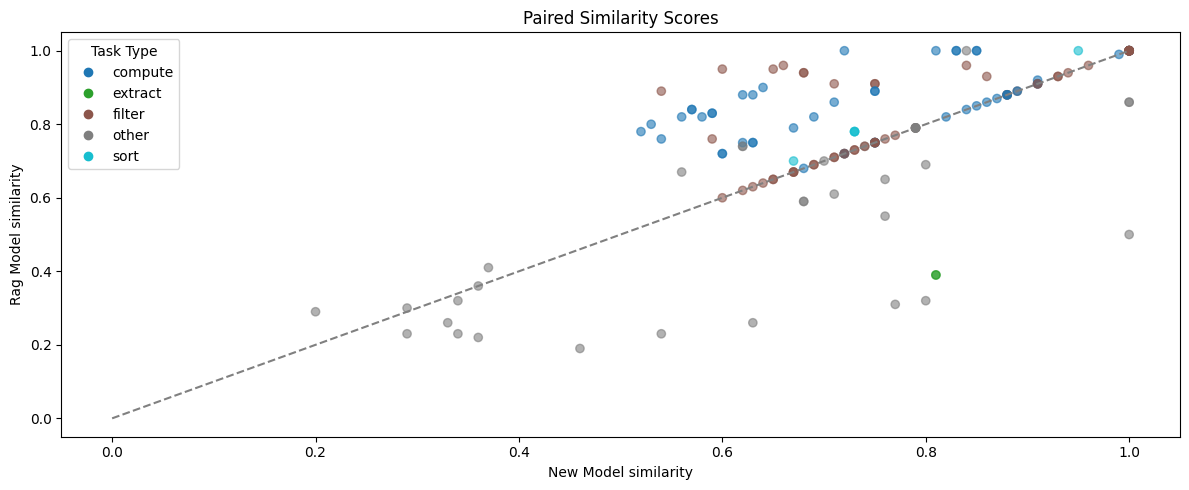

In [46]:
new_model2 = new_model.sort_values('test_case_id').reset_index(drop=True)
base_model2 = rag_model.sort_values('test_case_id').reset_index(drop=True)
plt.figure(figsize=(12,5))

# Encode task_type as categories
cats = new_model2['task_type'].astype('category')
codes = cats.cat.codes
labels = cats.cat.categories

# Scatter
scatter = plt.scatter(
    x=new_model2["similarity_score"],
    y=base_model2["similarity_score"],
    c=codes,
    alpha=0.6,
    cmap="tab10"
)

# Identity line
plt.plot([0,1], [0,1], linestyle="--", color="gray")

# Build legend manually
handles = [
    plt.Line2D(
        [0], [0],
        marker='o',
        linestyle='',
        color=scatter.cmap(scatter.norm(i)),
        label=label
    )
    for i, label in enumerate(labels)
]

plt.legend(handles=handles, title="Task Type")

plt.xlabel("New Model similarity")
plt.ylabel("Rag Model similarity")
plt.title("Paired Similarity Scores")

plt.tight_layout()
plt.show()